In [61]:
import pandas as pd
from bs4 import BeautifulSoup
import requests
import numpy as np
import yfinance as yf
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import skew
import miceforest as mf

## 1) Scraping GICS from Wikipedia:

Scraping from wikipedia the GICS Sector info and saving it to an excel file:

In [62]:
# url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
# response = requests.get(url)
# soup = BeautifulSoup(response.text, 'html.parser')
# table = soup.find('tbody')
# data = []
# rows = table.find_all('tr')
# for row in rows:
#   cells = row.find_all('td')
#   row_data = [cell.get_text(strip=True) for cell in cells]
#   data.append(row_data)

# symbol_wiki = pd.DataFrame(data)
# columns = ['Symbol', 'Security', 'GICS Sector', 'GICS Sub-Industry', 'Headquarters Location', 'Date Added', 'CIK', 'Founded']
# symbol_wiki.columns = columns
# symbol_wiki = symbol_wiki.iloc[1:]
# #print(symbol_wiki.head())
#symbol_wiki.to_excel("Data/symbol_wiki.xlsx", index = False)

Load the excel file with the GICS Sector information associated to the Symbol:

In [63]:
symbol_wiki = pd.read_excel("Data/wiki/symbol_wiki.xlsx")

In [64]:
symbol_wiki.head()

,Symbol,Security,GICS Sector,GICS Sub-Industry,Headquarters Location,Date Added,CIK,Founded
0,MMM,3M,Industrials,Industrial Conglomerates,"Saint Paul, Minnesota",1957-03-04,66740,1902
1,AOS,A. O. Smith,Industrials,Building Products,"Milwaukee, Wisconsin",2017-07-26,91142,1916
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,"North Chicago, Illinois",1957-03-04,1800,1888
3,ABBV,AbbVie,Health Care,Biotechnology,"North Chicago, Illinois",2012-12-31,1551152,2013 (1888)
4,ACN,Accenture,Information Technology,IT Consulting & Other Services,"Dublin, Ireland",2011-07-06,1467373,1989


Read the dataset with the symbol for each company of the S&P 500 (composition of december 2022) from LSEG Workspace, to match it with GICS data from wikipedia:

In [65]:
type_lseg = pd.read_excel("Data/lseg/constituents_symbols/symbol_comp_1221.xlsm", sheet_name="SYMBOL", dtype=str).iloc[0].values[1:]
symbol_lseg = pd.read_excel("Data/lseg/constituents_symbols/symbol_comp_1221.xlsm", sheet_name="SYMBOL", dtype=str, header=2)
symbol_lseg = symbol_lseg.iloc[:1].transpose().reset_index().rename(columns= {"index": "NAME", 0: "SYMBOL"}).iloc[1:]
symbol_lseg['TYPE'] = type_lseg
gics = pd.merge(symbol_lseg, symbol_wiki[['Symbol', 'GICS Sector']], how = 'left', left_on = 'SYMBOL', right_on='Symbol')

In [66]:
gics.head()

,NAME,SYMBOL,TYPE,Symbol,GICS Sector
0,AMAZON.COM,AMZN,891399,AMZN,Consumer Discretionary
1,ABBOTT LABORATORIES,ABT,916328,ABT,Health Care
2,AES,AES,545101,AES,Utilities
3,ABIOMED DEAD - DELIST.23/12/22,ABMD,777953,NaN,NaN
4,INTERNATIONAL BUS.MCHS.,IBM,906187,IBM,Information Technology


In [67]:
gics.shape

(505, 5)

In [68]:
gics.loc[gics['SYMBOL'].isna()]

,NAME,SYMBOL,TYPE,Symbol,GICS Sector


In [69]:
gics.loc[gics['SYMBOL'] != gics['Symbol']]

,NAME,SYMBOL,TYPE,Symbol,GICS Sector
3,ABIOMED DEAD - DELIST.23/12/22,ABMD,777953,NaN,NaN
9,ALASKA AIR GROUP,ALK,921794,NaN,NaN
34,BERKSHIRE HATHAWAY 'B',BRK.A,874227,NaN,NaN
41,BIO-RAD LABORATORIES 'A',BIO,992765,NaN,NaN
45,ROBERT HALF,RHI,923649,NaN,NaN
46,BORGWARNER,BWA,329709,NaN,NaN
67,CITRIX SYS. DEAD - DELIST.03/10/22,CTXS,867705,NaN,NaN
68,CERNER DEAD - DELIST.09/06/22,CERN,741643,NaN,NaN
79,COMERICA,CMA,922964,NaN,NaN
86,SEALED AIR,SEE,923036,NaN,NaN


## 2) Fill the missing GICS values manually from online sources:

In [70]:
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "ROBERT HALF"), 'GICS Sector'] = 'Industrials'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "ALASKA AIR GROUP"), 'GICS Sector'] = 'Industrials'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "AMERICAN AIRLINES GROUP"), 'GICS Sector'] = 'Industrials'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "BIO-RAD LABORATORIES 'A'"), 'GICS Sector'] = 'Health Care'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "TELEFLEX"), 'GICS Sector'] = 'Health Care'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "ILLUMINA"), 'GICS Sector'] = 'Health Care'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "CATALENT DEAD - DELIST.18/12/24"), 'GICS Sector'] = 'Health Care'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "DENTSPLY SIRONA"), 'GICS Sector'] = 'Health Care'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "ORGANON"), 'GICS Sector'] = 'Health Care'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "ETSY"), 'GICS Sector'] = 'Consumer Discretionary'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "BORGWARNER"), 'GICS Sector'] = 'Consumer Discretionary'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "V F"), 'GICS Sector'] = 'Consumer Discretionary'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "WHIRLPOOL"), 'GICS Sector'] = 'Consumer Discretionary'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "BATH AND BODY WORKS"), 'GICS Sector'] = 'Consumer Discretionary'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "ADV.AUTO PARTS"), 'GICS Sector'] = 'Consumer Discretionary'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "WESTROCK DEAD - DELIST.08/07/24"), 'GICS Sector'] = 'Materials'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "CELANESE"), 'GICS Sector'] = 'Materials'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "FMC"), 'GICS Sector'] = 'Materials'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "SEALED AIR"), 'GICS Sector'] = 'Materials'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "PIONEER NTRL.RES. DEAD - DELIST.03/05/24"), 'GICS Sector'] = 'Energy'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "MARATHON OIL DEAD - DELIST.22/11/24"), 'GICS Sector'] = 'Energy'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "ZIONS BANCORP."), 'GICS Sector'] = 'Financials'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "COMERICA"), 'GICS Sector'] = 'Financials'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "DISCOVER FINANCIAL SVS. DEAD - DELIST.19/05/25"), 'GICS Sector'] = 'Financials'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "BERKSHIRE HATHAWAY 'B'"), 'GICS Sector'] = 'Financials'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "LINCOLN NATIONAL"), 'GICS Sector'] = 'Financials'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "SVB FINANCIAL GROUP DEAD - DELIST.08/11/24"), 'GICS Sector'] = 'Financials'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "SIGNATURE BANK"), 'GICS Sector'] = 'Financials'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "FIRST REPUBLIC BANK"), 'GICS Sector'] = 'Financials'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "QORVO"), 'GICS Sector'] = 'Information Technology'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "SOLAREDGE TECHNOLOGIES"), 'GICS Sector'] = 'Information Technology'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "DXC TECHNOLOGY"), 'GICS Sector'] = 'Information Technology'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "DISH NETWORK 'A' DEAD - DELIST.02/01/24"), 'GICS Sector'] = 'Communication Services'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "ACTIVISION BLIZZARD DEAD - DELIST.16/10/23"), 'GICS Sector'] = 'Communication Services'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "LUMEN TECHNOLOGIES"), 'GICS Sector'] = 'Communication Services'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "NEWELL BRANDS (XSC)"), 'GICS Sector'] = 'Consumer Staples'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "VORNADO REALTY TRUST"), 'GICS Sector'] = 'Real Estate'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "ABIOMED DEAD - DELIST.23/12/22"), 'GICS Sector'] = 'Health Care'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "CITRIX SYS. DEAD - DELIST.03/10/22"), 'GICS Sector'] = 'Information Technology'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "CERNER DEAD - DELIST.09/06/22"), 'GICS Sector'] = 'Health Care'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "DUKE REALTY DEAD - DELIST.03/10/22"), 'GICS Sector'] = 'Real Estate'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "GAP"), 'GICS Sector'] = 'Consumer Discretionary'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "PENN ENTERTAINMENT"), 'GICS Sector'] = 'Consumer Discretionary'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "IPG PHOTONICS"), 'GICS Sector'] = 'Information Technology'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "XILINX DEAD - DELIST.15/02/22"), 'GICS Sector'] = 'Information Technology'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "UNDER ARMOUR A"), 'GICS Sector'] = 'Consumer Discretionary'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "UNDER ARMOUR 'C'"), 'GICS Sector'] = 'Consumer Discretionary'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "PEOPLES UNITED FINANCIAL DEAD - DELIST.05/04/22"), 'GICS Sector'] = 'Financials'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "FORTUNE BRANDS INNOVATIONS"), 'GICS Sector'] = 'Industrials'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "IHS MARKIT DEAD - DELIST.28/02/22"), 'GICS Sector'] = 'Industrials'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "PVH"), 'GICS Sector'] = 'Consumer Discretionary'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "TWITTER DEAD - DELIST.28/10/22"), 'GICS Sector'] = 'Communication Services'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "PARAMOUNT SKYDANCE B"), 'GICS Sector'] = 'Communication Services'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "NIELSEN DEAD - DELIST.12/10/22"), 'GICS Sector'] = 'Industrials'

In [71]:
gics.loc[gics['SYMBOL'].isin(['CARR', 'OGN', 'OTIS']), ['SYMBOL', 'GICS Sector']]

,SYMBOL,GICS Sector
446,CARR,Industrials
447,OTIS,Industrials
460,OGN,Health Care


In [72]:
gics.loc[(gics['GICS Sector'].isna())]

,NAME,SYMBOL,TYPE,Symbol,GICS Sector


In [73]:
gics.groupby(['GICS Sector'])['NAME'].count()

GICS Sector
Communication Services    27
Consumer Discretionary    57
Consumer Staples          36
Energy                    21
Financials                75
Health Care               64
Industrials               76
Information Technology    64
Materials                 28
Real Estate               29
Utilities                 28
Name: NAME, dtype: int64

Change the Symbol of BERKSHIRE HATHAWAY 'B' from BRK.A to BRK-B as it is the correct symbol:

In [74]:
gics.loc[(gics['NAME'] == "BERKSHIRE HATHAWAY 'B'"), 'SYMBOL'] = 'BRK-B' 

## 3) Calculate the weights within sector, using adjusted close price for corporate splits and Free Float Number of Shares Outstanding

the weights are calculated as of the last market trading day of 2022.

Taking the last day of 2022 closing prices adjusted for corporate splits (from LSEG):

In [75]:
price = pd.read_excel("Data/lseg/prices_dividends/price_div_comp_1221.xlsm", sheet_name="CLOSE PRICE", header=3)
price = price.iloc[1:]
price = price.transpose()
price.columns = price.iloc[0]
price = price.iloc[1:]



# Convert column labels to datetime
price.columns = pd.to_datetime(price.columns, errors="coerce")

# Select the last trading day of 2021
price = price.loc[:, price.columns <= "2021-12-31"].iloc[:, -1]
print(price)
price.name = "Price last day Dec 21"




AMAZON.COM                         166.717
ABBOTT LABORATORIES                 140.74
AES                                   24.3
ABIOMED DEAD - DELIST.23/12/22      359.17
INTERNATIONAL BUS.MCHS.             133.66
                                    ...   
WEC ENERGY GROUP                     97.07
MONSTER BEVERAGE                   48.0199
LINDE (NYS)                       346.4299
SBA COMMS.                          389.02
CHARTER COMMS.CL.A                  651.97
Name: 2021-12-31 00:00:00, Length: 505, dtype: object


/opt/anaconda3/lib/python3.12/site-packages/pandas/core/indexes/base.py:7631: FutureWarning: Dtype inference on a pandas object (Series, Index, ExtensionArray) is deprecated. The Index constructor will keep the original dtype in the future. Call `infer_objects` on the result to get the old behavior.
  return Index(index_like, name=name, copy=copy)


Taking the last day of 2022 free float number of shares outstanding adjusted for corporate splits (from LSEG):

In [76]:
ffnosh = pd.read_excel("Data/lseg/prices_dividends/price_div_comp_1221.xlsm", sheet_name="FFNOSH", header=3)
ffnosh = ffnosh.iloc[1:]
ffnosh = ffnosh.transpose()
ffnosh.columns = ffnosh.iloc[0]
ffnosh = ffnosh.iloc[1:]
# Convert column labels to datetime
ffnosh.columns = pd.to_datetime(ffnosh.columns, errors="coerce")

# Select the last trading day of 2021
ffnosh= ffnosh.loc[:, ffnosh.columns <= "2021-12-31"].iloc[:, -1]

ffnosh.name = "ffnosh last day Dec 21"

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/indexes/base.py:7631: FutureWarning: Dtype inference on a pandas object (Series, Index, ExtensionArray) is deprecated. The Index constructor will keep the original dtype in the future. Call `infer_objects` on the result to get the old behavior.
  return Index(index_like, name=name, copy=copy)


In [77]:
ffnosh.index = ffnosh.index.str.replace(' - DS FREE FLOAT SHRE', '', regex=False)

In [78]:
ffnosh.head()

AMAZON.COM                        8479113
ABBOTT LABORATORIES               1768287
AES                                541002
ABIOMED DEAD - DELIST.23/12/22      38982
INTERNATIONAL BUS.MCHS.            776777
Name: ffnosh last day Dec 21, dtype: object

In [79]:
ffnosh = pd.DataFrame(ffnosh)
price = pd.DataFrame(price)

In [80]:
gics = pd.merge(gics, ffnosh, how = 'left', left_on = 'NAME', right_index=True)

In [81]:
gics = pd.merge(gics, price, how = 'left', left_on = 'NAME', right_index=True)

Checking for nans:

In [82]:
gics.loc[gics['Price last day Dec 21'].isna()]

,NAME,SYMBOL,TYPE,Symbol,GICS Sector,ffnosh last day Dec 21,Price last day Dec 21


In [83]:
gics.loc[gics['ffnosh last day Dec 21'].isna()]

,NAME,SYMBOL,TYPE,Symbol,GICS Sector,ffnosh last day Dec 21,Price last day Dec 21


In [84]:
gics = gics.loc[: , ['NAME', 'TYPE', 'SYMBOL', 'GICS Sector', 'ffnosh last day Dec 21', 'Price last day Dec 21']]

Calculating weights within sector:

In [85]:
gics.loc[gics['SYMBOL'] == 'BRK.A']

,NAME,TYPE,SYMBOL,GICS Sector,ffnosh last day Dec 21,Price last day Dec 21


In [86]:
# STEP 1: Group by SYMBOL to combine share classes -> in this way duplicates such as NWSA, FOXA, GOOGL are counted as one weight (bc their emissions are reported at the parent company level)
aggregated = gics.groupby('SYMBOL').apply(
    lambda df: pd.Series({
        'TYPE': df['TYPE'].iloc[0],
        'Company Name': df['NAME'].iloc[0],
        'GICS Sector': df['GICS Sector'].iloc[0],
        'Total ffnosh': df['ffnosh last day Dec 21'].sum(),
        'Weighted Price': (df['ffnosh last day Dec 21'] * df['Price last day Dec 21']).sum() / df['ffnosh last day Dec 21'].sum()
    })
).reset_index()

# STEP 2: Calculate float-adjusted market cap
aggregated['float_mcap'] = aggregated['Total ffnosh'] * aggregated['Weighted Price']

# STEP 3: Compute sector totals
sector_total = aggregated.groupby('GICS Sector')['float_mcap'].transform('sum')

# STEP 4: Compute weight within sector
aggregated['weight_in_sector'] = aggregated['float_mcap'] / sector_total

# Optional: sort by sector or weight
aggregated = aggregated.sort_values(by=['GICS Sector', 'weight_in_sector'], ascending=[True, False])

/var/folders/n9/cy4s67js3v58hhczg4lxj5jr0000gq/T/ipykernel_61111/2632443762.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  aggregated = gics.groupby('SYMBOL').apply(


NB:

Free float = the number of shares available for trading in the market.

Excludes shares held by:

Founders

Governments

Strategic long-term investors (who won’t sell in the market)

In [87]:
gics[gics['SYMBOL'].duplicated(keep=False)]

,NAME,TYPE,SYMBOL,GICS Sector,ffnosh last day Dec 21,Price last day Dec 21
352,UNDER ARMOUR A,31610N,UAA,Consumer Discretionary,168801,21.19
369,WARNER BROS DISCOVERY SERIES A,31196R,WBD,Communication Services,160178,23.54
370,DISCOVERY SERIES C DEAD - DELIST.11/04/22,54099E,WBD,Communication Services,288812,22.9
417,NEWS 'A',89257H,NWSA,Communication Services,311859,22.31
418,NEWS 'B',89257J,NWSA,Communication Services,108971,22.5
423,UNDER ARMOUR 'C',7025QJ,UAA,Consumer Discretionary,211116,18.04
442,FOX A,9406MC,FOXA,Communication Services,281346,36.9
443,FOX B,9406MA,FOXA,Communication Services,149173,34.27
493,ALPHABET 'A',29026M,GOOGL,Communication Services,5559312,144.8519
499,ALPHABET 'C',871997,GOOGL,Communication Services,5584680,144.6796


In [88]:
pd.merge(gics, aggregated[['TYPE', 'weight_in_sector', 'float_mcap']], how = 'left', left_on = 'TYPE', right_on = 'TYPE').loc[pd.merge(gics, aggregated[['TYPE', 'weight_in_sector', 'float_mcap']], how = 'left', left_on = 'TYPE', right_on = 'TYPE')['SYMBOL']=='GOOGL']

,NAME,TYPE,SYMBOL,GICS Sector,ffnosh last day Dec 21,Price last day Dec 21,weight_in_sector,float_mcap
493,ALPHABET 'A',29026M,GOOGL,Communication Services,5559312,144.8519,0.423678,1.613266e+09
499,ALPHABET 'C',871997,GOOGL,Communication Services,5584680,144.6796,NaN,NaN


After grouping by SYMBOL, each company has one weight_in_sector. When merging back, only one of the share classes (TYPE) keeps the weight, the other appears as NaN. This avoids double-counting and I can therefore merge on Type:

In [89]:
gics = pd.merge(gics, aggregated[['TYPE', 'weight_in_sector', 'float_mcap']], how = 'left', left_on = 'TYPE', right_on = 'TYPE') 

In [90]:
gics.loc[gics['GICS Sector'] == 'Communication Services']['weight_in_sector'].sum()

1.0

In [91]:
gics.loc[gics['GICS Sector'] == 'Consumer Discretionary']['weight_in_sector'].sum()

1.0

In [92]:
len(gics)

505

In [93]:
gics.groupby(['GICS Sector'])['weight_in_sector'].sum()

GICS Sector
Communication Services    1.0
Consumer Discretionary    1.0
Consumer Staples          1.0
Energy                    1.0
Financials                1.0
Health Care               1.0
Industrials               1.0
Information Technology    1.0
Materials                 1.0
Real Estate               1.0
Utilities                 1.0
Name: weight_in_sector, dtype: float64

## 4) Read and merge scope emissions data

In [94]:
scope_emission_1  = pd.read_excel("Data/lseg/scope_emissions/carbon_int_comp_1221.xlsm", sheet_name="SCOPE 1", header=4).iloc[107]
#print(scope_emission_1)
scope_emission_1.index = scope_emission_1.index.str.replace(r'\(.*?\)', '', regex=True).str.strip()
scope_emission_1 = pd.DataFrame(scope_emission_1)
scope_emission_1.columns = ['Scope 1']
scope_emission_1 = scope_emission_1.iloc[1:]
scope_emission_1.index.name = 'Type'

scope_emission_2  = pd.read_excel("Data/lseg/scope_emissions/carbon_int_comp_1221.xlsm", sheet_name="SCOPE 2", header=4).iloc[107]
scope_emission_2.index = scope_emission_2.index.str.replace(r'\(.*?\)', '', regex=True).str.strip()
scope_emission_2 = pd.DataFrame(scope_emission_2)
scope_emission_2.columns = ['Scope 2']
scope_emission_2 = scope_emission_2.iloc[1:]
scope_emission_2.index.name = 'Type'

scope_emission_3  = pd.read_excel("Data/lseg/scope_emissions/carbon_int_comp_1221.xlsm", sheet_name="SCOPE 3", header=4).iloc[107]
scope_emission_3.index = scope_emission_3.index.str.replace(r'\(.*?\)', '', regex=True).str.strip()
scope_emission_3 = pd.DataFrame(scope_emission_3)
scope_emission_3.columns = ['Scope 3']
scope_emission_3 = scope_emission_3.iloc[1:]
scope_emission_3.index.name = 'Type'

In [95]:
revenue = pd.read_excel("Data/lseg/scope_emissions/carbon_int_comp_1221.xlsm", sheet_name="REVENUE", header=4).iloc[1:].iloc[107]
revenue.index = revenue.index.str.replace(r'\(.*?\)', '', regex=True).str.strip()
revenue = pd.DataFrame(revenue)
revenue.columns = ['Revenue']
revenue = revenue.iloc[1:]
revenue.index.name = 'Type'

In [96]:
gics = pd.merge(gics, scope_emission_1, how = 'left', left_on='TYPE', right_index=True)
gics = pd.merge(gics, scope_emission_2, how = 'left', left_on='TYPE', right_index=True)
gics = pd.merge(gics, scope_emission_3, how = 'left', left_on='TYPE', right_index=True)
gics = pd.merge(gics, revenue, how = 'left', left_on = 'TYPE', right_index=True)

In [97]:
gics.loc[gics['SYMBOL'].isin(['GOOGL', 'NWSA', 'FOXA', 'UAA'])]

,NAME,TYPE,SYMBOL,GICS Sector,ffnosh last day Dec 21,Price last day Dec 21,weight_in_sector,float_mcap,Scope 1,Scope 2,Scope 3,Revenue
352,UNDER ARMOUR A,31610N,UAA,Consumer Discretionary,168801,21.19,0.001588,7.385426e+06,3614.0,33713.0,1630988.0,5903636.0
417,NEWS 'A',89257H,NWSA,Communication Services,311859,22.31,0.002471,9.409422e+06,12700.0,64000.0,866960.0,9879000.0
418,NEWS 'B',89257J,NWSA,Communication Services,108971,22.5,NaN,NaN,12700.0,64000.0,866960.0,9879000.0
423,UNDER ARMOUR 'C',7025QJ,UAA,Consumer Discretionary,211116,18.04,NaN,NaN,3614.0,33713.0,1630988.0,5903636.0
442,FOX A,9406MC,FOXA,Communication Services,281346,36.9,0.004069,1.549383e+07,14266.0,52944.0,11877.0,14913000.0
443,FOX B,9406MA,FOXA,Communication Services,149173,34.27,NaN,NaN,14266.0,52944.0,11877.0,14913000.0
493,ALPHABET 'A',29026M,GOOGL,Communication Services,5559312,144.8519,0.423678,1.613266e+09,91200.0,8045400.0,10034000.0,307394000.0
499,ALPHABET 'C',871997,GOOGL,Communication Services,5584680,144.6796,NaN,NaN,91200.0,8045400.0,10034000.0,307394000.0


In [98]:
gics.loc[gics['SYMBOL']== 'BRK.A']

,NAME,TYPE,SYMBOL,GICS Sector,ffnosh last day Dec 21,Price last day Dec 21,weight_in_sector,float_mcap,Scope 1,Scope 2,Scope 3,Revenue


So since the Scope emissions and Revenue are reported at parent company level I can now remove the duplicates by keeping the first row:

In [99]:
gics = gics[~gics['SYMBOL'].duplicated(keep='first')]

In [100]:
gics['Scope 1+2+3'] = gics[['Scope 1', 'Scope 2', 'Scope 3']].sum(axis = 1)
gics['Carbon Intensity'] = gics['Scope 1+2+3']/gics['Revenue']

In [101]:
missing_scopes_type = list(gics.loc[gics['Scope 1'].isna() & gics['Scope 2'].isna() & gics['Scope 3'].isna(), 'TYPE'].values)

In [102]:
missing_scopes = list(gics.loc[gics['Scope 1'].isna() & gics['Scope 2'].isna() & gics['Scope 3'].isna(), 'SYMBOL'].values)

In [103]:
missing_scopes = list(gics.loc[gics['Scope 1'].isna() & gics['Scope 2'].isna() & gics['Scope 3'].isna(), 'NAME'].values)

In [104]:
len(set(list(gics.loc[gics['Scope 1'].isna(), 'NAME'].values)).union(set(list(gics.loc[gics['Scope 2'].isna(), 'NAME'].values))))

37

In [105]:
scope_1_2_nan = set(list(gics.loc[gics['Scope 1'].isna(), 'NAME'].values)).union(set(list(gics.loc[gics['Scope 2'].isna(), 'NAME'].values)))

In [106]:
len(scope_1_2_nan)

37

In [107]:
scope_1_2_3_nan = scope_1_2_nan.union(set(list(gics.loc[gics['Scope 3'].isna(), 'NAME'].values)))

In [108]:
len(set(list(gics.loc[gics['Scope 3'].isna(), 'NAME'].values)))

136

In [109]:
len(scope_1_2_3_nan)

138

In [110]:
len(missing_scopes)

34

In [111]:
gics.loc[gics['NAME'].isin(scope_1_2_3_nan)]['GICS Sector'].value_counts().sort_index()/gics['GICS Sector'].value_counts().sort_index()

GICS Sector
Communication Services    0.260870
Consumer Discretionary    0.285714
Consumer Staples          0.194444
Energy                    0.476190
Financials                0.253333
Health Care               0.390625
Industrials               0.342105
Information Technology    0.218750
Materials                 0.142857
Real Estate               0.241379
Utilities                 0.142857
Name: count, dtype: float64

In [112]:
gics.loc[gics['NAME'].isin(scope_1_2_3_nan)]['GICS Sector'].value_counts().sort_index()

GICS Sector
Communication Services     6
Consumer Discretionary    16
Consumer Staples           7
Energy                    10
Financials                19
Health Care               25
Industrials               26
Information Technology    14
Materials                  4
Real Estate                7
Utilities                  4
Name: count, dtype: int64

In [113]:
gics.loc[gics['NAME'].isin(scope_1_2_3_nan)]['GICS Sector'].value_counts().sort_index()/gics['GICS Sector'].value_counts().sort_index()

GICS Sector
Communication Services    0.260870
Consumer Discretionary    0.285714
Consumer Staples          0.194444
Energy                    0.476190
Financials                0.253333
Health Care               0.390625
Industrials               0.342105
Information Technology    0.218750
Materials                 0.142857
Real Estate               0.241379
Utilities                 0.142857
Name: count, dtype: float64

In [114]:
gics.loc[gics['NAME'].isin(scope_1_2_3_nan)]['GICS Sector'].value_counts().sort_index()[['Consumer Discretionary', 'Consumer Staples', 'Energy', 'Industrials', 'Information Technology', 'Materials', 'Utilities']].sum()

81

In [115]:
gics.loc[gics['NAME'].isin(scope_1_2_3_nan)]['GICS Sector'].value_counts().sort_index()

GICS Sector
Communication Services     6
Consumer Discretionary    16
Consumer Staples           7
Energy                    10
Financials                19
Health Care               25
Industrials               26
Information Technology    14
Materials                  4
Real Estate                7
Utilities                  4
Name: count, dtype: int64

In [116]:
# gics.loc[gics['Carbon Intensity'].isna()]

SCOPE 3 IMPUTATION

In [117]:
gics.columns

Index(['NAME', 'TYPE', 'SYMBOL', 'GICS Sector', 'ffnosh last day Dec 21',
       'Price last day Dec 21', 'weight_in_sector', 'float_mcap', 'Scope 1',
       'Scope 2', 'Scope 3', 'Revenue', 'Scope 1+2+3', 'Carbon Intensity'],
      dtype='object')

In [118]:
# Filter the DataFrame to Financials sector
financials = gics[(gics['GICS Sector'] == 'Financials') & (gics['Scope 1'].notna()) & (gics['Scope 2'].notna()) & (gics['Scope 3'].notna())]

# Calculate percentage columns
financials['% Scope 1'] = financials['Scope 1'] / financials['Scope 1+2+3'] * 100
financials['% Scope 2'] = financials['Scope 2'] / financials['Scope 1+2+3'] * 100
financials['% Scope 3'] = financials['Scope 3'] / financials['Scope 1+2+3'] * 100
#print(financials['% Scope 1'].mean())
#print(financials['% Scope 2'].mean())
#print(financials['% Scope 3'].mean())

/var/folders/n9/cy4s67js3v58hhczg4lxj5jr0000gq/T/ipykernel_61111/3156623907.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  financials['% Scope 1'] = financials['Scope 1'] / financials['Scope 1+2+3'] * 100
/var/folders/n9/cy4s67js3v58hhczg4lxj5jr0000gq/T/ipykernel_61111/3156623907.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  financials['% Scope 2'] = financials['Scope 2'] / financials['Scope 1+2+3'] * 100
/var/folders/n9/cy4s67js3v58hhczg4lxj5jr0000gq/T/ipykernel_61111/3156623907.py:7: SettingWit

In [119]:
# Filter the DataFrame to Industrials sector
industrials = gics[(gics['GICS Sector'] == 'Industrials') & (gics['Scope 1'].notna()) & (gics['Scope 2'].notna()) & (gics['Scope 3'].notna())]

# Calculate percentage columns
industrials['% Scope 1'] = industrials['Scope 1'] / industrials['Scope 1+2+3'] * 100
industrials['% Scope 2'] = industrials['Scope 2'] / industrials['Scope 1+2+3'] * 100
industrials['% Scope 3'] = industrials['Scope 3'] / industrials['Scope 1+2+3'] * 100
#print(industrials['% Scope 1'].mean())
#print(industrials['% Scope 2'].mean())
#print(industrials['% Scope 3'].mean())

/var/folders/n9/cy4s67js3v58hhczg4lxj5jr0000gq/T/ipykernel_61111/319877813.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  industrials['% Scope 1'] = industrials['Scope 1'] / industrials['Scope 1+2+3'] * 100
/var/folders/n9/cy4s67js3v58hhczg4lxj5jr0000gq/T/ipykernel_61111/319877813.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  industrials['% Scope 2'] = industrials['Scope 2'] / industrials['Scope 1+2+3'] * 100
/var/folders/n9/cy4s67js3v58hhczg4lxj5jr0000gq/T/ipykernel_61111/319877813.py:7: Setting

- 20 manually (scraped from sust. reports) imputed scope 1 emissions (for 2 cases, I had the total scope 1+2+3)
- 19 manually (scraped from sust. reports) imputed scope 2 emissions (for 2 cases, I had the total scope 1+2+3)
- 16 manually (scraped from sust. reports) imputed scope 3 emissions (for 2 cases, I had the total scope 1+2+3)

In [120]:
# # Load the file (no index_col since NAME is now a regular column)
# data_patch = pd.read_csv("Data/scope_emissions_patch.csv")

# # Define which columns to patch (only Scope columns, not Year/source/note)
# patchable_cols = [col for col in data_patch.columns 
#                   if col.startswith('Scope') or col == 'Revenue']

# # Apply patches row by row
# for _, row in data_patch.iterrows():
#     company = row['NAME']
#     if company in gics['NAME'].values:
#         mask = gics['NAME'] == company
#         for col in patchable_cols:
#             value = row[col]
#             # Only patch if value exists and target is NaN
#             if pd.notna(value) and col in gics.columns:
#                 if gics.loc[mask, col].isna().any():
#                     gics.loc[mask, col] = value
#                     # Track which fields were manually imputed
#                     imputed_col = f'Manually Imputed {col}'
#                     if imputed_col not in gics.columns:
#                         gics[imputed_col] = 0
#                     gics.loc[mask, imputed_col] = 1

We still have:
- 19 cases where scope 1 & 2 & 3 are all nans
- 1 where only scope 2 and scope 3 is na
- 104 cases where only scope 3 is nan

In [121]:
import itertools

# Define the columns
scope_cols = ['Scope 1', 'Scope 2', 'Scope 3']

# Generate all combinations of True (NaN) and False (not NaN)
combinations = list(itertools.product([True, False], repeat=3))

# Loop through each combination and filter the DataFrame
for comb in combinations:
    condition = (
        (gics['Scope 1'].isna() if comb[0] else gics['Scope 1'].notna()) &
        (gics['Scope 2'].isna() if comb[1] else gics['Scope 2'].notna()) &
        (gics['Scope 3'].isna() if comb[2] else gics['Scope 3'].notna())
    )
    
    filtered = gics.loc[condition]
    print(f"Combination (Scope 1 NaN: {comb[0]}, Scope 2 NaN: {comb[1]}, Scope 3 NaN: {comb[2]})")
    print(len(filtered))
    print("-" * 80)


Combination (Scope 1 NaN: True, Scope 2 NaN: True, Scope 3 NaN: True)
34
--------------------------------------------------------------------------------
Combination (Scope 1 NaN: True, Scope 2 NaN: True, Scope 3 NaN: False)
0
--------------------------------------------------------------------------------
Combination (Scope 1 NaN: True, Scope 2 NaN: False, Scope 3 NaN: True)
0
--------------------------------------------------------------------------------
Combination (Scope 1 NaN: True, Scope 2 NaN: False, Scope 3 NaN: False)
1
--------------------------------------------------------------------------------
Combination (Scope 1 NaN: False, Scope 2 NaN: True, Scope 3 NaN: True)
1
--------------------------------------------------------------------------------
Combination (Scope 1 NaN: False, Scope 2 NaN: True, Scope 3 NaN: False)
1
--------------------------------------------------------------------------------
Combination (Scope 1 NaN: False, Scope 2 NaN: False, Scope 3 NaN: True)
10

- 4 cases where Revenue was nan and found online:

In [122]:
gics.loc[gics['Revenue'].isna()]

,NAME,TYPE,SYMBOL,GICS Sector,ffnosh last day Dec 21,Price last day Dec 21,weight_in_sector,float_mcap,Scope 1,Scope 2,Scope 3,Revenue,Scope 1+2+3,Carbon Intensity
3,ABIOMED DEAD - DELIST.23/12/22,777953,ABMD,Health Care,38982,359.17,0.002781,14001164.94,NaN,NaN,NaN,NaN,0,NaN
67,CITRIX SYS. DEAD - DELIST.03/10/22,867705,CTXS,Information Technology,98468,94.59,0.000966,9314088.12,NaN,NaN,NaN,NaN,0,NaN
68,CERNER DEAD - DELIST.09/06/22,741643,CERN,Health Care,277312,92.87,0.005116,25753965.44,NaN,NaN,NaN,NaN,0,NaN
101,DUKE REALTY DEAD - DELIST.03/10/22,513260,DRE,Real Estate,355743,65.64,0.022342,23350970.52,NaN,NaN,NaN,NaN,0,NaN
204,ACTIVISION BLIZZARD DEAD - DELIST.16/10/23,312367,ATVI,Communication Services,739749,66.53,0.012925,49215500.97,2892.0,12309.0,261406.0,NaN,276607.0,NaN
280,SVB FINANCIAL GROUP DEAD - DELIST.08/11/24,518628,SIVBQ,Financials,55426,678.24,0.007548,37592130.24,NaN,NaN,NaN,NaN,0,NaN
335,XILINX DEAD - DELIST.15/02/22,543542,XLNX,Information Technology,233229,212.03,0.005129,49451544.87,NaN,NaN,NaN,NaN,0,NaN
339,SIGNATURE BANK,28709C,SBNY,Financials,52737,323.47,0.003425,17058837.39,NaN,NaN,NaN,NaN,0,NaN
358,PEOPLES UNITED FINANCIAL DEAD - DELIST.05/04/22,517465,PBCT,Financials,397769,17.82,0.001423,7088243.58,NaN,NaN,NaN,NaN,0,NaN
389,FIRST REPUBLIC BANK,72929C,FRCB,Financials,170160,206.51,0.007056,35139741.60,NaN,NaN,NaN,NaN,0,NaN


In [123]:
gics.loc[gics['NAME'] == 'ACTIVISION BLIZZARD DEAD - DELIST.16/10/23', 'Revenue'] = 8800000000
gics.loc[gics['NAME'] == 'SVB FINANCIAL GROUP DEAD - DELIST.08/11/24', 'Revenue'] = 5910000000
gics.loc[gics['NAME'] == 'SIGNATURE BANK', 'Revenue'] = 3700000000
gics.loc[gics['NAME'] == 'FIRST REPUBLIC BANK', 'Revenue'] = 5000000000

gics.loc[gics['NAME'] == 'ABIOMED DEAD - DELIST.23/12/22', 'Revenue'] = 847500000
gics.loc[gics['NAME'] == 'CITRIX SYS. DEAD - DELIST.03/10/22', 'Revenue'] = 3220000000
gics.loc[gics['NAME'] == 'CERNER DEAD - DELIST.09/06/22', 'Revenue'] = 5760000000
gics.loc[gics['NAME'] == 'DUKE REALTY DEAD - DELIST.03/10/22', 'Revenue'] = 1106000000
gics.loc[gics['NAME'] == 'XILINX DEAD - DELIST.15/02/22', 'Revenue'] = 3150000000
gics.loc[gics['NAME'] == 'PEOPLES UNITED FINANCIAL DEAD - DELIST.05/04/22', 'Revenue'] = 2740000000
gics.loc[gics['NAME'] == 'IHS MARKIT DEAD - DELIST.28/02/22', 'Revenue'] = 4650000000
gics.loc[gics['NAME'] == 'TWITTER DEAD - DELIST.28/10/22', 'Revenue'] = 5080000000
gics.loc[gics['NAME'] == 'NIELSEN DEAD - DELIST.12/10/22', 'Revenue'] = 3500000000

In [124]:
gics.loc[gics['Revenue'].isna()]

,NAME,TYPE,SYMBOL,GICS Sector,ffnosh last day Dec 21,Price last day Dec 21,weight_in_sector,float_mcap,Scope 1,Scope 2,Scope 3,Revenue,Scope 1+2+3,Carbon Intensity


In [125]:
# gics_original = gics.copy()
# gics = gics.loc[~gics.NAME.isin(scope_1_2_nan)]

In [126]:
# Create dummies separately
sector_dummies = pd.get_dummies(gics['GICS Sector'], prefix='Sector')

# Concatenate the original DataFrame with dummies
gics = pd.concat([gics, sector_dummies], axis=1)


In [127]:
len(gics)

500

In [128]:

# Ensure Scope 3 is numeric
scope3_obs = pd.to_numeric(gics["Scope 3"], errors="coerce").dropna()

skewness = skew(scope3_obs)

#print(f"Skewness: {skewness:.2f}")



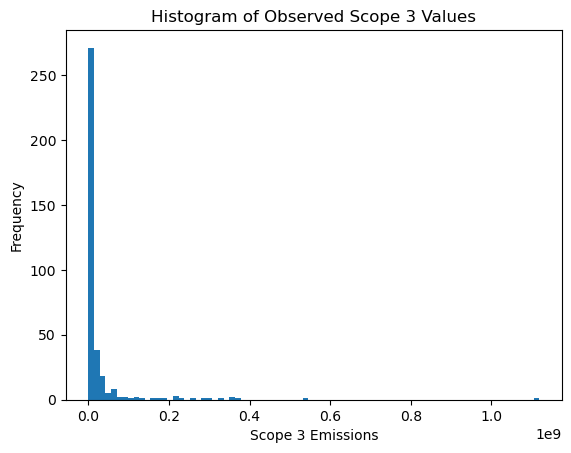

In [129]:

plt.hist(scope3_obs, bins=80)
plt.title("Histogram of Observed Scope 3 Values")
plt.xlabel("Scope 3 Emissions")
plt.ylabel("Frequency")
plt.show()


In [130]:
#print(f"Min: {scope3_obs.min()}, Max: {scope3_obs.max()}")


In [131]:
gics.loc[gics['NAME'] == 'DOLLAR GENERAL', ['Revenue', 'Scope 1', 'Scope 2', 'Scope 3']]

,Revenue,Scope 1,Scope 2,Scope 3
392,37844863.0,658617.0,1258232.0,NaN


In [132]:
gics.isna().any()

NAME                             False
TYPE                             False
SYMBOL                           False
GICS Sector                      False
ffnosh last day Dec 21           False
Price last day Dec 21            False
weight_in_sector                 False
float_mcap                       False
Scope 1                           True
Scope 2                           True
Scope 3                           True
Revenue                          False
Scope 1+2+3                      False
Carbon Intensity                  True
Sector_Communication Services    False
Sector_Consumer Discretionary    False
Sector_Consumer Staples          False
Sector_Energy                    False
Sector_Financials                False
Sector_Health Care               False
Sector_Industrials               False
Sector_Information Technology    False
Sector_Materials                 False
Sector_Real Estate               False
Sector_Utilities                 False
dtype: bool

In [133]:
gics.loc[gics['SYMBOL'].isin(['NWSA', 'FOXA', 'GOOGL']), ['NAME', 'ffnosh last day Dec 21', 'float_mcap', 'Price last day Dec 21', 'Scope 1', 'Scope 2', 'Scope 3', 'Revenue']]

,NAME,ffnosh last day Dec 21,float_mcap,Price last day Dec 21,Scope 1,Scope 2,Scope 3,Revenue
417,NEWS 'A',311859,9.409422e+06,22.31,12700.0,64000.0,866960.0,9879000.0
442,FOX A,281346,1.549383e+07,36.9,14266.0,52944.0,11877.0,14913000.0
493,ALPHABET 'A',5559312,1.613266e+09,144.8519,91200.0,8045400.0,10034000.0,307394000.0


In [134]:
len(gics)

500

In [135]:
gics = gics[~gics['SYMBOL'].duplicated(keep='first')]

In [136]:
len(gics)

500

In [137]:
gics.loc[gics['SYMBOL'].isin(['NWSA', 'FOXA', 'GOOGL']), ['NAME', 'ffnosh last day Dec 21', 'float_mcap', 'Price last day Dec 21', 'Scope 1', 'Scope 2', 'Scope 3', 'Revenue']]

,NAME,ffnosh last day Dec 21,float_mcap,Price last day Dec 21,Scope 1,Scope 2,Scope 3,Revenue
417,NEWS 'A',311859,9.409422e+06,22.31,12700.0,64000.0,866960.0,9879000.0
442,FOX A,281346,1.549383e+07,36.9,14266.0,52944.0,11877.0,14913000.0
493,ALPHABET 'A',5559312,1.613266e+09,144.8519,91200.0,8045400.0,10034000.0,307394000.0


In [138]:

columns = ["Scope 1", "Scope 2", "Revenue", "float_mcap", "Carbon Intensity", "Scope 3"]
sector_columns = [col for col in gics.columns if col.startswith("Sector_")]
all_cols = columns + sector_columns
# Convert all boolean columns to int (0/1)
bool_cols = gics.select_dtypes(include='bool').columns
gics[bool_cols] = gics[bool_cols].astype(int)

# Subset the data
data = gics[all_cols].copy().reset_index(drop=True)
# Show all columns with object dtype
# Step 1: Get all object columns
object_cols = data.select_dtypes(include="object").columns

# Step 2: Convert them to float
for col in object_cols:
    data[col] = pd.to_numeric(data[col], errors='coerce')

# Initialize kernel (this builds multiple trees for imputation)
kernel = mf.ImputationKernel(
    data=data,
    num_datasets=3,
    mean_match_candidates=5,
    random_state=1
)

# Run MICE with PMM
kernel.mice(5)  # 5 iterations

# Extract imputed dataset
completed_data = kernel.complete_data(dataset=0)
# Identify missing Scope 3 values before imputation
missing_mask_original = gics["Scope 3"].isna() 
# Replace back into original
gics.reset_index(drop=True, inplace=True)
missing_mask = gics["Scope 3"].isna() 
gics.loc[gics['Scope 1'].isna(), "Scope 1 Imputed"] = 1
gics.loc[gics['Scope 2'].isna(), "Scope 2 Imputed"] = 1
gics.loc[gics['Scope 3'].isna(), "Scope 3 Imputed"] = 1


In [139]:
completed_data.iloc[387]

Scope 1                          1.220600e+04
Scope 2                          6.080800e+04
Revenue                          6.443600e+06
float_mcap                       4.639700e+06
Carbon Intensity                 2.041987e-01
Scope 3                          1.242761e+06
Sector_Communication Services    0.000000e+00
Sector_Consumer Discretionary    1.000000e+00
Sector_Consumer Staples          0.000000e+00
Sector_Energy                    0.000000e+00
Sector_Financials                0.000000e+00
Sector_Health Care               0.000000e+00
Sector_Industrials               0.000000e+00
Sector_Information Technology    0.000000e+00
Sector_Materials                 0.000000e+00
Sector_Real Estate               0.000000e+00
Sector_Utilities                 0.000000e+00
Name: 387, dtype: float64

In [140]:
gics.loc[gics['NAME'] == 'DOLLAR GENERAL', ['Revenue', 'Scope 1', 'Scope 2', 'Scope 3']]

,Revenue,Scope 1,Scope 2,Scope 3
391,37844863.0,658617.0,1258232.0,NaN


In [141]:
gics['Scope 1'] = completed_data["Scope 1"]
gics['Scope 2'] = completed_data["Scope 2"]
gics["Scope 3"] = completed_data["Scope 3"]

In [142]:
completed_data.iloc[387]

Scope 1                          1.220600e+04
Scope 2                          6.080800e+04
Revenue                          6.443600e+06
float_mcap                       4.639700e+06
Carbon Intensity                 2.041987e-01
Scope 3                          1.242761e+06
Sector_Communication Services    0.000000e+00
Sector_Consumer Discretionary    1.000000e+00
Sector_Consumer Staples          0.000000e+00
Sector_Energy                    0.000000e+00
Sector_Financials                0.000000e+00
Sector_Health Care               0.000000e+00
Sector_Industrials               0.000000e+00
Sector_Information Technology    0.000000e+00
Sector_Materials                 0.000000e+00
Sector_Real Estate               0.000000e+00
Sector_Utilities                 0.000000e+00
Name: 387, dtype: float64

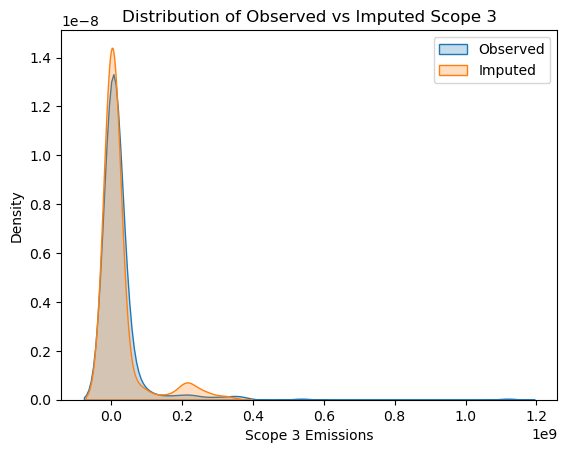

In [143]:
# Separate imputed and observed
imputed_values = gics.loc[missing_mask, "Scope 3"]
observed_values = gics.loc[~missing_mask, "Scope 3"]

# Plot
sns.kdeplot(observed_values, label="Observed", fill=True)
sns.kdeplot(imputed_values, label="Imputed", fill=True)
plt.title("Distribution of Observed vs Imputed Scope 3")
plt.xlabel("Scope 3 Emissions")
plt.ylabel("Density")
plt.legend()
plt.show()

- to do: calculate point to point deviation between observed scope 3 and predicted, could look at scatter plot by sector

In [144]:
gics['Scope 1+2+3'] = gics[['Scope 1', 'Scope 2', 'Scope 3']].sum(axis = 1)
gics['Carbon Intensity'] = gics['Scope 1+2+3']/gics['Revenue']
gics.isna().any()

NAME                             False
TYPE                             False
SYMBOL                           False
GICS Sector                      False
ffnosh last day Dec 21           False
Price last day Dec 21            False
weight_in_sector                 False
float_mcap                       False
Scope 1                          False
Scope 2                          False
Scope 3                          False
Revenue                          False
Scope 1+2+3                      False
Carbon Intensity                 False
Sector_Communication Services    False
Sector_Consumer Discretionary    False
Sector_Consumer Staples          False
Sector_Energy                    False
Sector_Financials                False
Sector_Health Care               False
Sector_Industrials               False
Sector_Information Technology    False
Sector_Materials                 False
Sector_Real Estate               False
Sector_Utilities                 False
Scope 1 Imputed          

In [145]:
gics.loc[gics['GICS Sector'] == 'Communication Services']

,NAME,TYPE,SYMBOL,GICS Sector,ffnosh last day Dec 21,Price last day Dec 21,weight_in_sector,float_mcap,Scope 1,Scope 2,...,Sector_Financials,Sector_Health Care,Sector_Industrials,Sector_Information Technology,Sector_Materials,Sector_Real Estate,Sector_Utilities,Scope 1 Imputed,Scope 2 Imputed,Scope 3 Imputed
21,COMCAST A,981550,CMCSA,Communication Services,4559479,50.33,0.060266,2.294786e+08,496938.00,1480893.00,...,0,0,0,0,0,0,0,NaN,NaN,NaN
38,VERIZON COMMUNICATIONS,945384,VZ,Communication Services,4140164,51.96,0.056496,2.151229e+08,273904.00,3498643.00,...,0,0,0,0,0,0,0,NaN,NaN,NaN
49,TAKE TWO INTACT.SFTW.,889831,TTWO,Communication Services,108012,177.72,0.005041,1.919589e+07,1868.00,14892.00,...,0,0,0,0,0,0,0,NaN,NaN,NaN
96,WALT DISNEY,921964,DIS,Communication Services,1680481,154.89,0.068358,2.602897e+08,993347.00,782066.00,...,0,0,0,0,0,0,0,NaN,NaN,1.0
99,OMNICOM GROUP,932913,OMC,Communication Services,199690,73.27,0.003842,1.463129e+07,32915.00,34362.00,...,0,0,0,0,0,0,0,NaN,NaN,NaN
108,DISH NETWORK 'A' DEAD - DELIST.02/01/24,135448,DISH,Communication Services,243871,32.44,0.002078,7.911175e+06,29543.05,70013.00,...,0,0,0,0,0,0,0,1.0,1.0,1.0
111,ELECTRONIC ARTS,500320,EA,Communication Services,253441,131.9,0.008779,3.342887e+07,3875.00,19570.00,...,0,0,0,0,0,0,0,NaN,NaN,NaN
166,INTERPUBLIC GROUP,923465,IPG,Communication Services,331833,37.45,0.003264,1.242715e+07,11193.00,36553.00,...,0,0,0,0,0,0,0,NaN,NaN,NaN
204,ACTIVISION BLIZZARD DEAD - DELIST.16/10/23,312367,ATVI,Communication Services,739749,66.53,0.012925,4.921550e+07,2892.00,12309.00,...,0,0,0,0,0,0,0,NaN,NaN,NaN
289,AT&T,945388,T,Communication Services,6783929,18.6153,0.033165,1.262849e+08,917036.00,4962516.00,...,0,0,0,0,0,0,0,NaN,NaN,NaN


## 5) Recalculate weights in sector and market cap only for the sectors of CEG and OGN

In [146]:
gics_missing_sectors_name = gics.loc[gics['SYMBOL'].isin(['OTIS', 'OGN', 'CARR']), 'GICS Sector']
gics = gics.loc[~gics['SYMBOL'].isin(['CARR', 'OTIS', 'OGN'])]

In [147]:
gics_missing_sectors_name

442    Industrials
443    Industrials
456    Health Care
Name: GICS Sector, dtype: object

In [148]:
# STEP 0: Assume `gics` is your original DataFrame
# Columns: SYMBOL, ffnosh, Price, GICS Sector

gics_missing_sectors_filtered_df = gics.loc[gics['GICS Sector'].isin(gics_missing_sectors_name.values)]
print(gics_missing_sectors_filtered_df)
# STEP 1: Group by SYMBOL to combine share classes
aggregated = gics_missing_sectors_filtered_df.groupby('SYMBOL').apply(
    lambda df: pd.Series({
        'TYPE': df['TYPE'].iloc[0],
        'Company Name': df['NAME'].iloc[0],
        'GICS Sector': df['GICS Sector'].iloc[0],
        'Total ffnosh': df['ffnosh last day Dec 21'].sum(),
        'Weighted Price': (df['ffnosh last day Dec 21'] * df['Price last day Dec 21']).sum() / df['ffnosh last day Dec 21'].sum()
    })
).reset_index()

# STEP 2: Calculate float-adjusted market cap
aggregated['float_mcap'] = aggregated['Total ffnosh'] * aggregated['Weighted Price']

# STEP 3: Compute sector totals
sector_total = aggregated.groupby('GICS Sector')['float_mcap'].transform('sum')

# STEP 4: Compute weight within sector
aggregated['weight_in_sector'] = aggregated['float_mcap'] / sector_total

# Optional: sort by sector or weight
aggregated = aggregated.sort_values(by=['GICS Sector', 'weight_in_sector'], ascending=[True, False])

                               NAME    TYPE SYMBOL  GICS Sector  \
1               ABBOTT LABORATORIES  916328    ABT  Health Care   
3    ABIOMED DEAD - DELIST.23/12/22  777953   ABMD  Health Care   
9                  ALASKA AIR GROUP  921794    ALK  Industrials   
12                  HONEYWELL INTL.  906191    HON  Industrials   
13                            AMGEN  938692   AMGN  Health Care   
..                              ...     ...    ...          ...   
474                       MEDTRONIC  906496    MDT  Health Care   
480  NIELSEN DEAD - DELIST.12/10/22  72467E   NLSN  Industrials   
482          JOHNSON CONTROLS INTL.  545615    JCI  Industrials   
483                 DENTSPLY SIRONA  510209   XRAY  Health Care   
486                         FORTIVE  7552EK    FTV  Industrials   

    ffnosh last day Dec 21 Price last day Dec 21  weight_in_sector  \
1                  1768287                140.74          0.049440   
3                    38982                359.17       

/var/folders/n9/cy4s67js3v58hhczg4lxj5jr0000gq/T/ipykernel_61111/646314816.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  aggregated = gics_missing_sectors_filtered_df.groupby('SYMBOL').apply(


In [149]:
len(aggregated)

137

In [150]:
gics.loc[gics['GICS Sector'].isin(gics_missing_sectors_name), ['weight_in_sector', 'float_mcap']] = np.nan

In [151]:
gics = pd.merge(gics, aggregated[['SYMBOL', 'weight_in_sector', 'float_mcap']], how = 'left', left_on = 'SYMBOL', right_on = 'SYMBOL')

In [152]:
gics['weight_in_sector_x'] = gics['weight_in_sector_x'].fillna(gics['weight_in_sector_y'])
gics['float_mcap_x'] =  gics['float_mcap_x'].fillna(gics['float_mcap_y'])

In [153]:
gics['weight_in_sector'] = gics['weight_in_sector_x']
gics.drop(columns=['weight_in_sector_x', 'weight_in_sector_y'], inplace=True)

gics['float_mcap'] = gics['float_mcap_x']
gics.drop(columns=['float_mcap_x', 'float_mcap_y'], inplace=True)



In [154]:
len(gics)

497

In [155]:
gics.groupby(['GICS Sector'])['weight_in_sector'].sum()

GICS Sector
Communication Services    1.0
Consumer Discretionary    1.0
Consumer Staples          1.0
Energy                    1.0
Financials                1.0
Health Care               1.0
Industrials               1.0
Information Technology    1.0
Materials                 1.0
Real Estate               1.0
Utilities                 1.0
Name: weight_in_sector, dtype: float64

## 6) Fetch from Yahoo finance the adjusted price for corporate splits and dividends/capital gains (on LSEG is only adjusted for splits) -> to calculate covariance matrix

In [156]:
# # Define the tickers and date range
# tickers = list(gics['SYMBOL'].values) # Add more tickers as needed
# start_date = "2019-12-01"
# end_date = "2022-12-31"

# # Download the data
# data = yf.download(tickers, start=start_date, end=end_date, group_by='ticker', auto_adjust=False, progress=False)

# # Extract adjusted close prices
# adj_close = pd.DataFrame()

# # If only one ticker, yfinance doesn't use a multi-indexed DataFrame, handle accordingly
# if len(tickers) == 1:
#     adj_close[tickers[0]] = data['Adj Close']
# else:
#     for ticker in tickers:
#         try:
#             adj_close[ticker] = data[ticker]['Adj Close']
#         except KeyError:
#             #print(f"No data found for {ticker}.")

# # Display the result
# #print(adj_close.head())



9 Failed downloads:
['SBNY']: YFPricesMissingError('possibly delisted; no price data found  (1d 2019-12-01 -> 2022-12-30) (Yahoo error = "Data doesn\'t exist for startDate = 1575176400, endDate = 1672376400")')
['DISH', 'CTLT', 'WRK', 'ATVI', 'MRO', 'SIVBQ', 'PXD']: YFTzMissingError('possibly delisted; no timezone found')
['BF.B']: YFPricesMissingError('possibly delisted; no price data found  (1d 2019-12-01 -> 2022-12-30)')


In [157]:
# #print(gics.loc[gics['SYMBOL'] == 'BF.B'])
# # Define the tickers and date range
# tickers = ['BF-B'] # Add more tickers as needed
# start_date = "2019-12-01"
# end_date = "2022-12-31"

# # Download the data
# data_bfb = yf.download(tickers, start=start_date, end=end_date, group_by='ticker', auto_adjust=False, progress=False)

# # Extract adjusted close prices
# adj_close_bfb = pd.DataFrame()

# # If only one ticker, yfinance doesn't use a multi-indexed DataFrame, handle accordingly
# if len(tickers) == 1:
#     adj_close_bfb[tickers[0]] = data_bfb['BF-B']['Adj Close']
# else:
#     for ticker in tickers:
#         try:
#             adj_close_bfb[ticker] = data_bfb[ticker]['Adj Close']
#         except KeyError:
#             #print(f"No data found for {ticker}.")

# # Display the result
# #print(adj_close_bfb.head())
# adj_close['BF.B'] = adj_close_bfb.values

In [158]:
# adj_close.to_excel("Data/adj_prices_yahoo_comp_1222.xlsm")

In [159]:
adj_close = pd.read_excel("Data/yahoo/adj_prices_yahoo_comp_1222.xlsm")
adj_close.index = adj_close.Date
adj_close.drop(columns='Date', inplace=True)

In [160]:
len(set(gics['SYMBOL'].unique()) - set(adj_close.columns))

16

In [161]:
len(set(adj_close.columns) - set(gics['SYMBOL'].unique()))

19

In [162]:
adj_close = adj_close.drop(columns=set(adj_close.columns) - set(gics['SYMBOL'].unique()))

In [163]:
# # Define the tickers and date range
# tickers = list(set(gics['SYMBOL'].unique()) - set(adj_close.columns)) # Add more tickers as needed
# start_date = "2019-12-01"
# end_date = "2022-12-31"

# # Download the data
# data_missing_yahoo = yf.download(tickers, start=start_date, end=end_date, group_by='ticker', auto_adjust=False, progress=False)

# # Extract adjusted close prices
# adj_close_missing = pd.DataFrame()

# # If only one ticker, yfinance doesn't use a multi-indexed DataFrame, handle accordingly
# if len(tickers) == 1:
#     adj_close_missing[tickers[0]] = data_missing_yahoo[tickers]['Adj Close']
# else:
#     for ticker in tickers:
#         try:
#             adj_close_missing[ticker] = data_missing_yahoo[ticker]['Adj Close']
#         except KeyError:
#             print(f"No data found for {ticker}.")

# # Display the result
# print(adj_close_missing.head())
# for ticker in tickers:
#     adj_close[ticker] = adj_close_missing[ticker].values

In [164]:
#set(gics['SYMBOL'].unique()) - set(adj_close.columns)

In [165]:
#adj_close.to_excel("Data/lseg/adj_prices_yahoo_comp_1221.xlsm")

In [166]:
adj_close = pd.read_excel("Data/yahoo/adj_prices_yahoo_comp_1221.xlsm")
adj_close.index = adj_close.Date
adj_close.drop(columns='Date', inplace=True)

In [167]:
len(adj_close.columns)

497

## 7) Fill in missing data from adjusted prices calculated manually or by refetching from Yahoo with the correct Symbol:

In [168]:
price = pd.read_excel('Data/lseg/prices_dividends/price_div_comp_1222.xlsm', sheet_name='CLOSE PRICE', header = 4)
price.columns = price.columns.str.replace(r'\(.*?\)', '', regex=True).str.strip()
#print(price.iloc[239:])
price = price.iloc[239:]
print(price)

           Code   891399  916328  545101    906187  936365    749382  891631  \
239  2019-12-02  89.0800   84.51   18.92  126.9509   38.73  302.7500  159.61   
240  2019-12-03  88.4980   84.36   18.84  126.1963   38.90  303.9099  161.28   
241  2019-12-04  88.0345   85.18   18.90  126.0722   39.69  302.5100  160.07   
242  2019-12-05  87.0240   85.24   18.81  125.9958   39.62  303.0300  161.07   
243  2019-12-06  87.5800   85.48   18.72  127.2470   39.63  306.2300  161.94   
...         ...      ...     ...     ...       ...     ...       ...     ...   
1039 2022-12-26  85.2500  108.18   28.68  141.6500   64.52  338.4500  147.24   
1040 2022-12-27  83.0400  108.57   28.82  142.4200   63.27  335.0901  146.45   
1041 2022-12-28  81.8200  107.83   28.32  140.0200   62.57  328.3301  143.45   
1042 2022-12-29  84.1800  110.31   28.81  141.0600   64.82  337.5801  145.20   
1043 2022-12-30  84.0000  109.79   28.76  140.8900   64.77  336.5300  145.67   

        905271  921794  ...  9801CK  91

In [169]:
price = pd.read_excel('Data/lseg/prices_dividends/price_div_comp_1221.xlsm', sheet_name='CLOSE PRICE', header = 4)
price.columns = price.columns.str.replace(r'\(.*?\)', '', regex=True).str.strip()
print(price)

          Code    891399  916328  545101  777953    906187  936365    749382  \
0   2019-01-01   75.0985   72.33   14.46  325.04  108.5735   18.46  226.2400   
1   2019-01-02   76.9565   69.50   14.18  309.96  110.0445   18.83  224.5700   
2   2019-01-03   75.0140   66.22   14.17  302.29  107.8476   17.05  215.7000   
3   2019-01-04   78.7695   68.11   14.64  313.44  112.0599   19.00  226.1900   
4   2019-01-07   81.4755   69.13   14.71  314.80  112.8527   20.57  229.2600   
..         ...       ...     ...     ...     ...       ...     ...       ...   
844 2022-03-28  168.9905  119.99   24.65  321.81  131.4700  120.24  450.0100   
845 2022-03-29  169.3150  120.19   25.45  331.50  131.9400  123.23  466.3301   
846 2022-03-30  166.3010  120.38   25.45  328.51  132.1300  119.22  460.0601   
847 2022-03-31  162.9975  118.36   25.73  331.24  130.0200  109.34  455.6201   
848 2022-04-01  163.5600  118.58   26.22  338.64  130.1500  108.19  458.1899   

     891631  905271  ...  8660JC  9801C

In [170]:
# suppose your DataFrame is called df
start = "2019-12-31"
end   = "2022-01-01"

adj_close = adj_close.loc[start:end]

In [171]:
price = pd.read_excel('Data/lseg/prices_dividends/price_div_comp_1221.xlsm', sheet_name='CLOSE PRICE', header = 4)
price.columns = price.columns.str.replace(r'\(.*?\)', '', regex=True).str.strip()

div_rate = pd.read_excel('Data/lseg/prices_dividends/price_div_comp_1221.xlsm', sheet_name='DIV RATE', header = 4)
div_rate.columns = div_rate.columns.str.replace(r'\(.*?\)', '', regex=True).str.strip() 

div_date = pd.read_excel('Data/lseg/prices_dividends/price_div_comp_1221.xlsm', sheet_name='DIV DATE', header = 4)
div_date.columns = div_date.columns.str.replace(r'\(.*?\)', '', regex=True).str.strip()

div_date.columns = price.columns
div_rate.columns = price.columns

price.index = price.Code
div_rate.index = div_rate.Code
div_date.index = div_date.Code

price = price[start:end] 
div_rate = div_rate[start:end]
div_date = div_date[start:end] 

price = price.iloc[:, 1:]
div_rate = div_rate.iloc[:, 1:]
div_date = div_date.iloc[:, 1:]

# --- Step 1: Calculate adjustment factors
adj_factors = pd.DataFrame(1.0, index=price.index, columns=price.columns)

for company in price.columns:
    for i in range(1, len(price)):
        date = price.index[i]
        prev_date = price.index[i - 1]

        # If ex-dividend happens on this day
        if pd.notna(div_date.at[date, company]):
            div = div_rate.at[date, company]
            price_prev = price.at[prev_date, company]
            if price_prev and price_prev != 0:
                factor = (price_prev - div) / price_prev
                adj_factors.at[date, company] = factor

# --- Step 2: Calculate cumulative adjustment factors in reverse (like Yahoo)
cum_factors = adj_factors.iloc[::-1].cumprod().iloc[::-1]

# --- Step 3: Build adjusted prices
adjusted_prices_calculated = price * cum_factors

#print(gics.loc[gics['SYMBOL'] == 'WRK', 'NAME'])
#print(div_rate['96699P'].unique())
#print(price['96699P'])
#print(adjusted_prices_calculated['96699P'])
adj_close['WRK'] = adjusted_prices_calculated.loc[adj_close.index, '96699P'].values

#print(gics.loc[gics['SYMBOL'] == 'CTLT', 'NAME'])
#print(div_rate['8866F3'].unique())
#print(price['8866F3'])
#print(adjusted_prices_calculated['8866F3'])
adj_close['CTLT'] = adjusted_prices_calculated.loc[adj_close.index, ['8866F3']].values

#print(gics.loc[gics['SYMBOL'] == 'MRO', 'NAME'])
#print(div_rate['544682'].unique())
#print(price['544682'])
#print(adjusted_prices_calculated['544682'])
adj_close['MRO'] = adjusted_prices_calculated.loc[adj_close.index, '544682'].values

#print(gics.loc[gics['SYMBOL'] == 'PXD', 'NAME'])
#print(div_rate['895705'].unique())
#print(price['895705'])
adj_close['PXD'] = adjusted_prices_calculated.loc[adj_close.index, '895705'].values

#print(gics.loc[gics['SYMBOL'] == 'SBNY', ['NAME','TYPE']])
#print(div_rate['28709C'].unique())
#print(price['28709C'])
adj_close['SBNY'] = adjusted_prices_calculated.loc[adj_close.index, '28709C'].values

#print(gics.loc[gics['SYMBOL'] == 'ATVI', ['NAME','TYPE']])
#print(div_rate['312367'].unique())
#print(price['312367'])
adj_close['ATVI'] = adjusted_prices_calculated.loc[adj_close.index, '312367'].values

#print(gics.loc[gics['SYMBOL'] == 'DISH', ['NAME','TYPE']])
#print(div_rate['135448'].unique())
#print(price['135448'])
adj_close['DISH'] = adjusted_prices_calculated.loc[adj_close.index, '135448'].values

#print(gics.loc[gics['SYMBOL'] == 'SIVBQ', ['NAME','TYPE']])
#print(div_rate['518628'].unique())
#print(price['518628'])
adj_close['SIVBQ'] = adjusted_prices_calculated.loc[adj_close.index, '518628'].values

for stock in ['CTXS', 'PBCT', 'NLSN', 'CERN', 'TWTR', 'XLNX', 'DRE', 'ABMD', 'INFO']:
    type_stock_missing = gics.loc[gics['SYMBOL'] == stock, 'TYPE'].values
    print(adjusted_prices_calculated)
    adj_close[stock] = adjusted_prices_calculated.loc[adj_close.index,  type_stock_missing].values


              891399      916328     545101  777953      906187  936365  \
Code                                                                      
2019-12-31   92.3920   84.210196  18.777771  170.59  115.822932   45.86   
2020-01-01   92.3920   84.210196  18.777771  170.59  115.822932   45.86   
2020-01-02   94.9005   84.297450  18.900440  168.81  117.015446   49.10   
2020-01-03   93.7485   83.269787  18.683410  166.82  116.082206   48.60   
2020-01-06   95.1440   83.706059  18.900440  179.04  115.874859   48.39   
...              ...         ...        ...     ...         ...     ...   
2021-12-27  169.6695  141.460000  23.670000  357.83  131.620000  154.36   
2021-12-28  170.6610  140.470000  23.740000  357.44  132.630000  153.15   
2021-12-29  169.2010  141.190000  23.780000  361.84  133.350000  148.26   
2021-12-30  168.6445  141.000000  24.170000  362.06  133.910000  145.15   
2021-12-31  166.7170  140.740000  24.300000  359.17  133.660000  143.90   

              749382    

## 8) Calculate log monthly returns for past 2 years:

In [172]:
def calculate_log_monthly_returns(df):
    df = df.replace(0.0, np.nan).dropna(how="all")
    df_monthly = df.resample("M").last()
    df_monthly.index = df_monthly.index.map(lambda x: x.replace(day=15))
    log_returns = np.log(df_monthly).diff().dropna(how="all")
    return log_returns

In [173]:
len(adj_close)

506

In [174]:
log_returns = calculate_log_monthly_returns(adj_close)

/var/folders/n9/cy4s67js3v58hhczg4lxj5jr0000gq/T/ipykernel_61111/3896427440.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_monthly = df.resample("M").last()


In [175]:
cols_with_nans = adj_close.columns[adj_close.isna().any()]
print("Columns with NaNs:", cols_with_nans.tolist())

nan_columns = adj_close.loc[:, adj_close.isna().any(axis=0)]

for col in nan_columns.columns:
    first_valid = nan_columns[col].first_valid_index()
    print(f"First non-NaN in column '{col}': {first_valid}") # these stocks had later IPO


Columns with NaNs: []


In [176]:
from datetime import datetime
log_returns = log_returns.loc[log_returns.index > datetime(2019, 12, 15)]

In [177]:
for col in nan_columns.columns:
    first_valid = nan_columns[col].first_valid_index()
    print(f"First non-NaN in column '{col}': {first_valid}") # these stocks had later IPO

In [178]:
gics['rank_in_sector'] = gics.groupby('GICS Sector')['weight_in_sector'].rank(ascending=False)

In [179]:
cols_with_nan = log_returns.columns[log_returns.isna().any()]
log_returns_nan = log_returns[cols_with_nan]
log_returns_nan

""
Date
2020-01-15
2020-02-15
2020-03-15
2020-04-15
2020-05-15
2020-06-15
2020-07-15
2020-08-15
2020-09-15


In [180]:
gics

,NAME,TYPE,SYMBOL,GICS Sector,ffnosh last day Dec 21,Price last day Dec 21,Scope 1,Scope 2,Scope 3,Revenue,...,Sector_Information Technology,Sector_Materials,Sector_Real Estate,Sector_Utilities,Scope 1 Imputed,Scope 2 Imputed,Scope 3 Imputed,weight_in_sector,float_mcap,rank_in_sector
0,AMAZON.COM,891399,AMZN,Consumer Discretionary,8479113,166.717,13020000.0,3060000.0,49020000.0,574785000.0,...,0,0,0,0,NaN,NaN,NaN,0.304014,1.413612e+09,1.0
1,ABBOTT LABORATORIES,916328,ABT,Health Care,1768287,140.74,530000.0,476000.0,12829000.0,40109000.0,...,0,0,0,0,NaN,NaN,NaN,0.049516,2.488687e+08,5.0
2,AES,545101,AES,Utilities,541002,24.3,39931000.0,479000.0,3118000.0,12668000.0,...,0,0,0,1,NaN,NaN,NaN,0.014069,1.314635e+07,24.0
3,ABIOMED DEAD - DELIST.23/12/22,777953,ABMD,Health Care,38982,359.17,16813000.0,6400000.0,211542718.0,847500000,...,0,0,0,0,1.0,1.0,1.0,0.002786,1.400116e+07,56.0
4,INTERNATIONAL BUS.MCHS.,906187,IBM,Information Technology,776777,133.66,79000.0,330000.0,586000.0,61860000.0,...,1,0,0,0,NaN,NaN,NaN,0.010768,1.038240e+08,17.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
492,WEC ENERGY GROUP,902335,WEC,Utilities,293953,97.07,18865000.0,231000.0,28348000.0,8893000.0,...,0,0,0,1,NaN,NaN,NaN,0.030537,2.853402e+07,12.0
493,MONSTER BEVERAGE,512785,MNST,Consumer Staples,756958,48.0199,10077.0,8300.0,1854377.0,7140027.0,...,0,0,0,0,NaN,NaN,NaN,0.014765,3.634905e+07,17.0
494,LINDE (NYS),9373MH,LIN,Materials,512555,346.4299,16813000.0,20903000.0,25859001.0,32854000.0,...,0,1,0,0,NaN,NaN,NaN,0.182356,1.775644e+08,1.0
495,SBA COMMS.,699786,SBAC,Real Estate,102535,389.02,11100.0,21000.0,10917.0,2711584.0,...,0,0,1,0,NaN,NaN,1.0,0.038164,3.988817e+07,8.0


In [181]:
set(gics.SYMBOL) - set(log_returns.columns)

set()

## 9) Calculate covariance by sector:

In [182]:
data = gics[['GICS Sector', 'SYMBOL', 'weight_in_sector', 'Carbon Intensity']] 
cols_with_nan = data.columns[data.isna().any()]
data_nan = data[cols_with_nan]

In [183]:
# Create a dictionary to store covariance matrices by sector
sector_cov_matrices = {}
sector_log_returns = {}

# Loop over each unique GICS sector
for sector in data['GICS Sector'].unique():
    # Get list of symbols in this sector
    symbols_in_sector = data[(data['GICS Sector'] == sector)]['SYMBOL'].tolist()

    # Filter log_returns to only include columns (symbols) in this sector
    sector_returns = log_returns[symbols_in_sector]

    # Drop columns with all NaNs (in case any ticker has no returns)
    sector_returns = sector_returns.dropna(axis=1, how='all')

    # Calculate and store the covariance matrix
    if not sector_returns.empty:
        sector_log_returns[sector] = sector_returns.copy()
        sector_cov_matrices[sector] = sector_returns.cov()

# Optional: #print or inspect one example
example_sector = list(sector_cov_matrices.keys())[0]
#print(f"Covariance matrix for sector: {example_sector}")
#print(sector_cov_matrices[example_sector])

count_in_cov = 0
for key, value in sector_cov_matrices.items():
    count_in_cov += value.shape[0]
    #print(f"{key}: {value.shape}")
print(count_in_cov)
with pd.ExcelWriter("Data/log_returns/sector_cov_matrices_comp_1221.xlsx") as writer:
    for sector, cov_matrix in sector_cov_matrices.items():
        # Excel sheet names can't have certain characters or be too long
        safe_sector = sector[:31].replace('/', '_')
        cov_matrix.to_excel(writer, sheet_name=safe_sector)
with pd.ExcelWriter("Data/log_returns/sector_log_returns_comp_1221.xlsx") as writer:
    for sector, returns_df in sector_log_returns.items():
        safe_sector = sector[:31].replace('/', '_')
        returns_df.to_excel(writer, sheet_name=safe_sector)

497


In [184]:
count_in_cov

497

In [185]:
adj_close.to_excel("Data/yahoo/adj_price_yahoo_comp_1221.xlsx")

In [186]:
gics.to_excel("Data/datasets/dataset_comp_1221.xlsx")